In [46]:
# Import required libraries for data analysis and visualization

import pandas as pd          # For data manipulation
import numpy as np           # For numerical operations
import matplotlib.pyplot as plt   # For plotting graphs
import seaborn as sns        # For advanced visualizations

In [47]:
# Load the dataset
df = pd.read_csv('Zomato.csv')

# Display first 5 rows to understand the structure
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [48]:
# Check number of rows and columns
df.shape

# Check data types and missing values
df.info()

# Get statistical summary of numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [49]:
# Function to clean 'rate' column (extract numeric part before '/')
def handlerate(value):
    value = str(value).split('/')   # Split values like "4.2/5"
    value = value[0]                # Take only rating (4.2)
    return float(value)

# Apply function to 'rate' column
df['rate'] = df['rate'].apply(handlerate)

# Verify changes
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


# Analysis Questions & Answers

### Q1: What type of restaurant do the majority of customers order from?

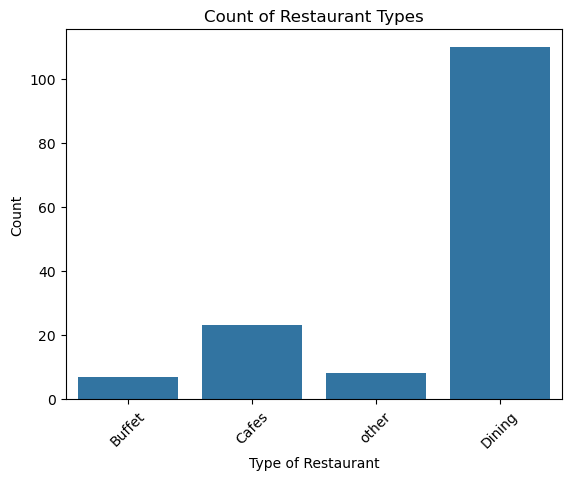

In [50]:
# Count number of restaurants in each category
sns.countplot(x='listed_in(type)', data=df)

plt.title('Count of Restaurant Types')
plt.xlabel('Type of Restaurant')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#### Answer:
#### The category with the highest bar represents the most common restaurant type.

### Q2: How many votes has each type of restaurant received?

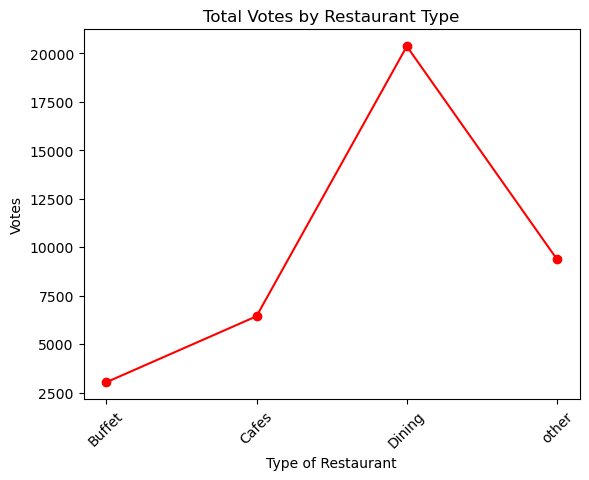

In [51]:
# Group data by restaurant type and sum votes
grouped_data = df.groupby('listed_in(type)')['votes'].sum()

# Plot results
plt.plot(grouped_data.index, grouped_data.values, c='red', marker='o')

plt.title('Total Votes by Restaurant Type')
plt.xlabel('Type of Restaurant')
plt.ylabel('Votes')
plt.xticks(rotation=45)
plt.show()

#### Answer:
#### Shows total customer engagement (votes) per category.
#### The type with highest value = most popular among users.

### Q3: What ratings do most restaurants have?

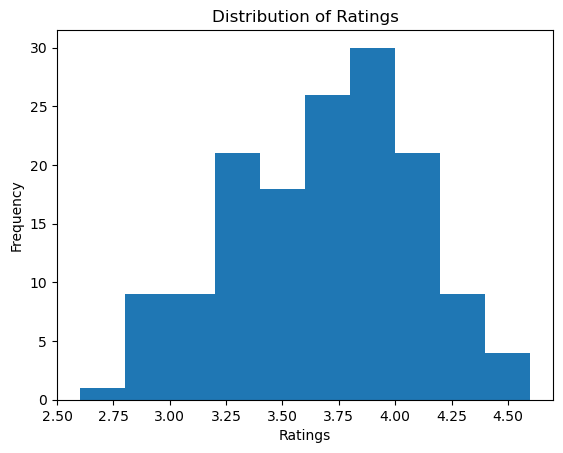

In [53]:
# Plot distribution of ratings
plt.hist(df['rate'], bins=10)

plt.title('Distribution of Ratings')
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.show()

#### Answer:
#### Most restaurants usually fall between 3.5 to 4.5 ratings.
#### Indicates generally good quality across restaurants.

### Q4: Do couples prefer online ordering?

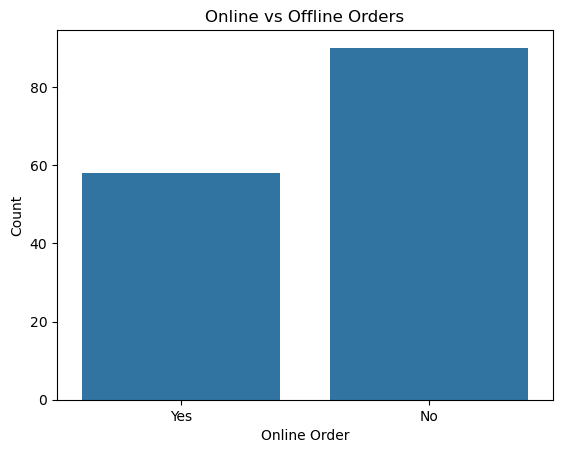

In [54]:
# Count online vs offline orders
sns.countplot(x='online_order', data=df)

plt.title('Online vs Offline Orders')
plt.xlabel('Online Order')
plt.ylabel('Count')
plt.show()

#### Answer:

#### If "Yes" is higher → couples prefer online ordering
#### Supports Zomato’s observation.

### Q5: Which mode (online/offline) has higher ratings?

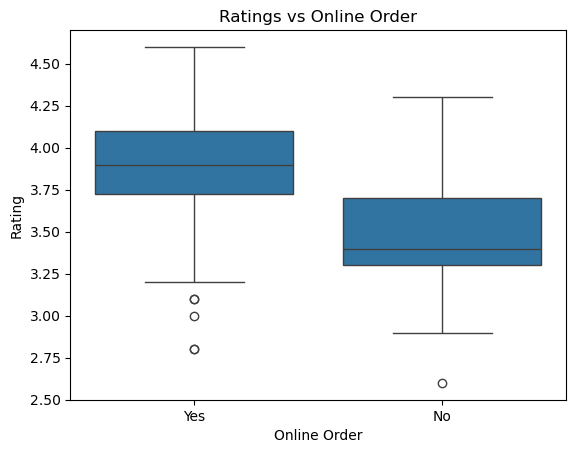

In [60]:
# Compare ratings based on order mode
sns.boxplot(x='online_order', y='rate', data=df)

plt.title('Ratings vs Online Order')
plt.xlabel('Online Order')
plt.ylabel('Rating')
plt.show()

#### Answer:

#### Higher median box = better ratings
#### Helps identify if online experience is better than offline

### Q6: Which type of restaurant receives more offline orders?

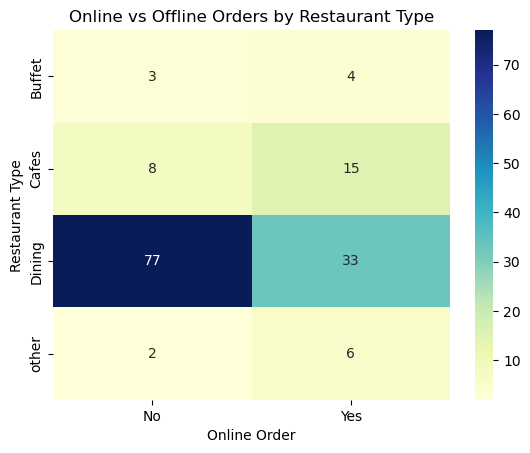

In [59]:
# Create pivot table
pivot_table = df.pivot_table(
    index='listed_in(type)', 
    columns='online_order', 
    aggfunc='size', 
    fill_value=0
)

# Heatmap visualization
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')

plt.title('Online vs Offline Orders by Restaurant Type')
plt.xlabel('Online Order')
plt.ylabel('Restaurant Type')
plt.show()

### Answer:

### Cells with higher values under "No" column = more offline orders
### Helps Zomato identify where to improve online services

# Final Insight Summary

Key Insights:
1. Most restaurants belong to Dinning.
2. Dinning received highest votes → most popular
3. Ratings mostly lie between 3.5–4.5
4. Online ordering is preferred by majority users
5. Online mode has better ratings
6. Certain restaurant types still rely heavily on offline orders

Business Impact:
- Zomato should focus on improving online experience for categories with low adoption
- High-vote categories can be targeted for promotions
